Este trabajo se realizo con el dataset de exoplanetas ya limpio y listo para preparar, donde buscamos clasificar un planeta como habitable o no habitable por medio de una referencia, la temperatura de equilibrio `pl_eqt`, la cual debe ser similar a la de la tierra (255 K), si cae dentro del rango de 200 - 300 K, puede considerarse habitable.

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# importar datos
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Inteligencia_Artificial_1/dataset_final_exoplanetas.csv')
df.head(5)

,pl_name,pl_eqt,pl_insol,st_teff,st_rad
0,11 Com b,1700.0,792.57818,4060.0,1.313160
1,11 UMi b,1450.0,372.74340,3100.0,0.840000
2,14 And b,1600.0,513.74032,3530.0,0.366450
3,14 Her b,2369.0,427.54252,2943.0,0.289776
4,16 Cyg B b,2677.0,5262.59620,7244.6,1.976258


Crear variable binaria para saber si un planeta es habitable o no

In [25]:
df['habitable'] = ((df['pl_eqt'] >= 273) & (df['pl_eqt'] <= 373)).astype(int)
print(df['habitable'].value_counts())
print(df['habitable'].dtype)

habitable
0    4337
1     229
Name: count, dtype: int64
int64


In [26]:
df.head(5)

,pl_name,pl_eqt,pl_insol,st_teff,st_rad,habitable
0,11 Com b,1700.0,792.57818,4060.0,1.313160,0
1,11 UMi b,1450.0,372.74340,3100.0,0.840000,0
2,14 And b,1600.0,513.74032,3530.0,0.366450,0
3,14 Her b,2369.0,427.54252,2943.0,0.289776,0
4,16 Cyg B b,2677.0,5262.59620,7244.6,1.976258,0


Dividiremos los datos con una proporcion de 70/30, tomando como referencia la lectura previa

In [27]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['pl_name', 'habitable', 'pl_eqt'])
y = df['habitable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

print(f"Registros de entrenamiento: {len(X_train)}")
print(f"Registros de prueba: {len(X_test)}")
print("\nDistribución en train:")
print(y_train.value_counts())
print("\nDistribución en test:")
print(y_test.value_counts())

Registros de entrenamiento: 2283
Registros de prueba: 2283

Distribución en train:
habitable
0    2168
1     115
Name: count, dtype: int64

Distribución en test:
habitable
0    2169
1     114
Name: count, dtype: int64


Antes de eso vayamos a confirmar que el conjunto de datos esta listo para usar, para eso utilicemos varias tecnicas, como el metodo de tukey para verificar los outliers y el porcentaje que estos conforman en el dataset, asi mismo verifiquemos si tenemos valores nulos o huecos, esto con el fin de satisfacer lo que viene estipulado en las instruciones de la tarea.

In [28]:
# ============================================================
# REVISIÓN FINAL DE LA BASE DE DATOS
# ============================================================
import pandas as pd
import numpy as np
# --- 1. Valores nulos ---
print("=" * 50)
print("VALORES NULOS")
print("=" * 50)
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(resumen_nulos)
print(f"\nTotal columnas con nulos: {len(resumen_nulos)}")

# --- 2. Outliers por método de Tukey (IQR) ---
print("\n" + "=" * 50)
print("OUTLIERS - MÉTODO DE TUKEY (IQR)")
print("=" * 50)

columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
resumen_outliers = []

for col in columnas_numericas:
    serie = df[col].dropna()
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    n_outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()
    pct = round(n_outliers / len(serie) * 100, 2)

    resumen_outliers.append({
        'Variable': col,
        'Q1': round(Q1, 4),
        'Q3': round(Q3, 4),
        'IQR': round(IQR, 4),
        'Límite inferior': round(limite_inf, 4),
        'Límite superior': round(limite_sup, 4),
        'Outliers': n_outliers,
        'Porcentaje (%)': pct
    })

df_outliers = pd.DataFrame(resumen_outliers).sort_values('Porcentaje (%)', ascending=False)
display(df_outliers)

# Resumen global
total_outliers = df_outliers['Outliers'].sum()
print(f"\nTotal de valores atípicos detectados: {total_outliers}")
print(f"Porcentaje promedio de outliers por variable: {df_outliers['Porcentaje (%)'].mean():.2f}%")

VALORES NULOS
Empty DataFrame
Columns: [Nulos, Porcentaje (%)]
Index: []

Total columnas con nulos: 0

OUTLIERS - MÉTODO DE TUKEY (IQR)


,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers,Porcentaje (%)
1,pl_insol,24.1035,397.099,372.9955,-535.3897,956.5922,521,11.41
2,st_teff,4999.2500,5927.750,928.5000,3606.5000,7320.5000,284,6.22
4,habitable,0.0000,0.000,0.0000,0.0000,0.0000,229,5.02
3,st_rad,0.7700,1.190,0.4200,0.1400,1.8200,190,4.16
0,pl_eqt,568.0000,1165.000,597.0000,-327.5000,2060.5000,100,2.19



Total de valores atípicos detectados: 1324
Porcentaje promedio de outliers por variable: 5.80%


Bien, parece que no hay valores nulos, esto es debido a que la base ya habia sido imputada con KNN, pero parece que siguen habiendo valores atipicos, de modo que podriamos tratar de llenarlos con KNN de la misma manera.

In [29]:
from sklearn.impute import KNNImputer
import numpy as np

columnas_modelo = ['pl_insol', 'st_teff', 'st_rad']

# --- 1. Convertir outliers a NaN usando Tukey ---
for col in columnas_modelo:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # Reemplazar outliers con NaN
    df[col] = np.where(
        (df[col] < limite_inf) | (df[col] > limite_sup),
        np.nan,
        df[col]
    )
    print(f"{col}: NaN después de marcar outliers: {df[col].isna().sum()}")

# --- 2. Imputar los NaN con KNN ---
imputer = KNNImputer(n_neighbors=5)
df[columnas_modelo] = imputer.fit_transform(df[columnas_modelo])

# --- 3. Verificar ---
print("\nOutliers restantes después de imputación:")
for col in columnas_modelo:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {outliers}")

pl_insol: NaN después de marcar outliers: 521
st_teff: NaN después de marcar outliers: 284
st_rad: NaN después de marcar outliers: 190

Outliers restantes después de imputación:
  pl_insol: 241
  st_teff: 14
  st_rad: 58


Muy interesante lo que estamo viendo, aun despues de haber aplicado el metodo de KNN para remplazar los valorea atipicos, parece que siguen habiendo valores extremos, esto podria sugerir que la naturaleza de algunos datos es real y no es un error de captura, por lo que para fines practicos lo dejaremos asi.

### Modelos

Con el fin de probar diversos modelos para ver el comportamiento y hacer conclusiones acerca de los modelos.

Entre los modelos que se van a probar estan

- Random Forest
- Boosting
- Support Vector Machine
- Redes Neuronales

## Modelo Random Forest

Utilizaremos unos 50 estimadores para el modelo

In [30]:
# Importar función
from sklearn.ensemble import RandomForestClassifier as RFC
# Generar y entrenar modelo
rf = RFC(50 , oob_score=True).fit(X_train,y_train)

Listo!, ya que entrenamos a nuestro modelo, vamos a evaluar su calidad, mediante F1 Score, Accuracy, prediccion, y OOB score

>Nota: esto se llevo a cabo utilizando los comandos de la lectura previa

In [31]:
# Realizar la predicción
from sklearn.metrics import accuracy_score, f1_score
predRF = rf.predict(X_test)
# Calcular accuracy
accRF = accuracy_score(y_test, predRF)
# Calcular f1
f1RF = f1_score(y_test, predRF, average="macro")
#Imprimir resultados
print("Accuracy de random forest:",accRF)
print("F1-score de random forest:",f1RF)
print("OOB score de random forest:",rf.oob_score_)

Accuracy de random forest: 0.9785370127025843
F1-score de random forest: 0.8814632952328678
OOB score de random forest: 0.9732807709154621


Vaya, interesantes resultados, parece que el modelo es bueno en general de modo que puede identificar correctamente casi todos los planetas en un 97.6%, con respecto al F1 score, sabiendo que es una combinacion de la precisión y el recall, el valor fue de 87.1 % de modo que al parecer le cuesta un poco el recall, posiblemente al desbalance de las clases, ya que tenemos muchos mas planetas No habitables que habitables. El OOB score, nos dice que en general el modelo es bastante bueno con datos que no utilizo durante en train

Ahora, demos un vistazo a la importancia de las variables, donde generaremos un indice donde se despliegue basado en su importancia, de mayor a menor

In [32]:
# Generar índice basado en importancia
ind = rf.feature_importances_.argsort()[::-1]
#Ciclo for para imprimir resultados
for index in ind:
    print(f'{X_test.columns[index]}: {rf.feature_importances_[index]:.4f}')


pl_insol: 0.7069
st_teff: 0.1513
st_rad: 0.1418


Al parecer la variable con mas importancia en el conjunto de datos es la de pl_insol, y las menos importantes, relativamente hablando, spm las de 0.1488 y 0.1401, ahora generamos una matriz de confusión para verlo de una forma mas grafica.

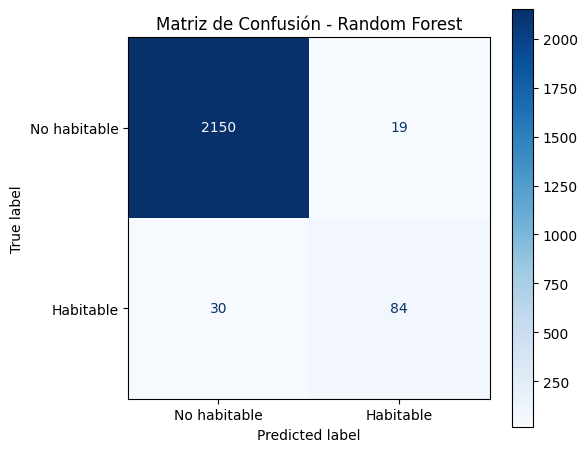

Verdaderos Negativos  (TN): 2150
Falsos Positivos      (FP): 19
Falsos Negativos      (FN): 30
Verdaderos Positivos  (TP): 84


In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generar matriz de confusión
cm = confusion_matrix(y_test, predRF)

# Visualizar
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No habitable', 'Habitable'])
disp.plot(cmap='Blues', ax=ax)

ax.set_title('Matriz de Confusión - Random Forest')
plt.tight_layout()
plt.show()

# Imprimir valores
print(f"Verdaderos Negativos  (TN): {cm[0,0]}")
print(f"Falsos Positivos      (FP): {cm[0,1]}")
print(f"Falsos Negativos      (FN): {cm[1,0]}")
print(f"Verdaderos Positivos  (TP): {cm[1,1]}")

Esto explica por qué el F1-score fue de 87.1% y no más alto, esos 32 falsos negativos son los que lo están bajando un poco, lo cual puede deberse al desbalance de las clases. En general el modelo se comporta bastante bien considerando que solo tenía 115 ejemplos de planetas habitables para aprender durante el entrenamiento.

## Modelo Boosting

Con el fin de ver el comportamiento de los datos ante diferentes modelos, hagamos ahora uno basado en el concepto de boosting, donde utilizaremos el mismo numero de estimadores '50', un learning rate de 0.1 y un max depth de 3

In [34]:
from sklearn.ensemble import GradientBoostingClassifier

# Entrenar modelo de Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

Ahora probemos la calidad del modelo de boosting

In [35]:

gb.fit(X_train, y_train)
# Predicción
predGB = gb.predict(X_test)

# Métricas
accGB = accuracy_score(y_test, predGB)
f1GB = f1_score(y_test, predGB, average="macro")

print(f"Accuracy de Gradient Boosting: {accGB}")
print(f"F1-score de Gradient Boosting: {f1GB}")

Accuracy de Gradient Boosting: 0.9759088918090232
F1-score de Gradient Boosting: 0.8766291505573378


Vaya, obtuvimos resultados ligeramente mas bajos que los de random forest, sin embargo, para fines practicos, son iguales.

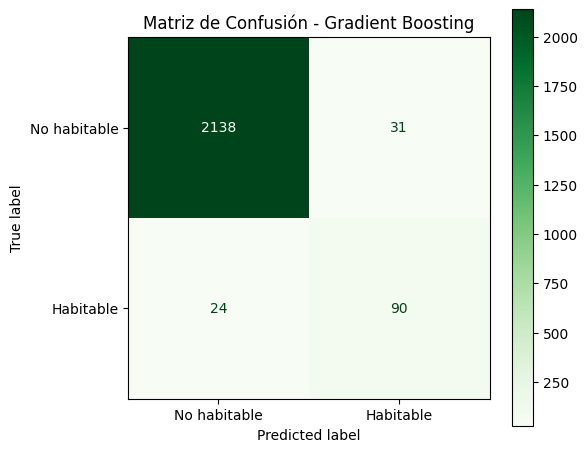

In [36]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, predGB),
                               display_labels=['No habitable', 'Habitable'])
disp.plot(cmap='Greens', ax=ax)
ax.set_title('Matriz de Confusión - Gradient Boosting')
plt.tight_layout()
plt.show()

Los resultados de la matriz de confusión son bastante similares, de modo que si prestamos atencion, ahora podemos apreciar que ahora con este modelo basado en boosting, podemos predecir mejor los planetas que SI son habitables, como consecuencia, perdemos un poco de precisión en los planetas los cuales no lo son, sin embargo, es una mejora muy significativa.

## Modelo SVM

Ahora, adentremonos un poco en el tema de los vectores, donde en Support Vector Machines, buscaremos la mejor linea que separe los datos para poder clasificar como habitable o no habitable.

In [37]:
from sklearn.svm import SVC

# Entrenar modelo SVM
svm = SVC(
    kernel='rbf',        # kernel radial, bueno para datos no lineales
    C=1.0,               # penalización por errores
    gamma='scale',       # escala automática
    class_weight='balanced',  # compensa el desbalance de clases
    random_state=42
)


Entrenar modelo y medir la calidad de las predicciones

In [38]:
svm.fit(X_train, y_train)

# Predicción
predSVM = svm.predict(X_test)

# Métricas
accSVM = accuracy_score(y_test, predSVM)
f1SVM = f1_score(y_test, predSVM, average="macro")

print(f"Accuracy de SVM: {accSVM}")
print(f"F1-score de SVM: {f1SVM}")

Accuracy de SVM: 0.5825667980727114
F1-score de SVM: 0.453340448930889


Vaya que es malo, al parecer solo puede predecir con exactitud el 58% de los planetas correctamente, en cuanto al F1-Score, vemos que le cuesta bastante el tener un balance entre precisión y recall.

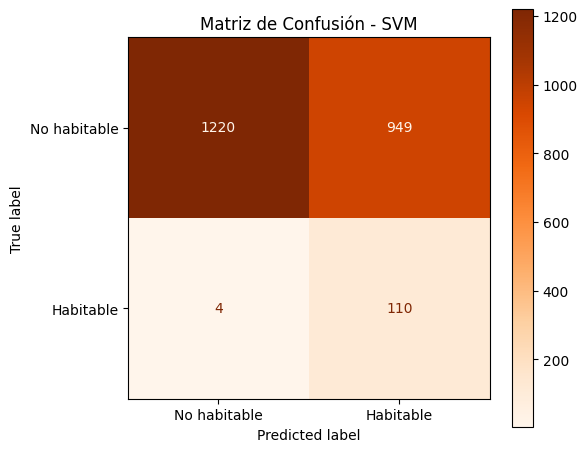

In [39]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, predSVM),
                               display_labels=['No habitable', 'Habitable'])
disp.plot(cmap='Oranges', ax=ax)
ax.set_title('Matriz de Confusión - SVM')
plt.tight_layout()
plt.show()

La matriz de confusión nos muestra lo que temiamos, el modelo es muy malo para clasificar cuales no son habitables, ya que como vemos, 949 planetas que no eran habitables el modelo las clasifico como habitable.

## Modelo de Red Neuronal

Bien!, en este apartado vamos a construir una red neuronal para poder predecir la habitabilidad de los planetas, para eso tendremos que definir parametros como las epocas, que son algo asi como los ciclos que tiene que completar el entrenamiento, el batch size, que en este caso seria que tanta informacion (planetas), esta manejando a la vez; el class weigth, el cual le dice al modelo que se equivocar en un planeta habitable es más costoso que en uno no habitable. Todos estos son parametros que tendremos que definir para construir la red neuronal.

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- 1. Construir la red neuronal ---
model = Sequential()

# Input layer: recibe las features directamente (no es imagen, no necesita Flatten)
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1,  activation='sigmoid'))  # salida binaria: habitable o no


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Definimos el numero de neuronas por capa, en este caso fueron 64, 32 y 1, respectivamente para la primera capa, la segunda y la salida.

In [52]:
# --- 2. Configurar fase de entrenamiento ---
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=0.001)
model.compile(
    optimizer=opt,
    loss='binary_crossentropy',  # clasificación binaria
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)

En esta tabla, basicamente nos estan diciendo que tantos parametros tenemos por capa, siendo la capa de 32 neuronas la que mas tiene parametros. En total tenemos 2,369 parametros en nuestro modelo, una cantidad relativamente pequeña, hablando en terminos de redes neuronales.

En este caso, utilizaremos los siguientes parametros:

- 50 epocas (ciclos)
- 32 batches (informacion procesada a la vez)
- 20 % Validacion del split (con cuanto porcentaje vamos a evaluar)
- 10 epocas de paciencia (que tantas epocas podemos esperar antes de que el modelo mejore)

In [53]:
# --- 3. Early stopping ---
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

# --- 4. Entrenar el modelo ---
history = model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stop],
    class_weight={0: 1, 1: 20}  # compensa el desbalance
)


Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5893 - loss: 30.0583 - val_accuracy: 0.5624 - val_loss: 2.7711
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7590 - loss: 2.3712 - val_accuracy: 0.7112 - val_loss: 1.0434
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6873 - loss: 9.3721 - val_accuracy: 0.2845 - val_loss: 37.6541
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5838 - loss: 27.4216 - val_accuracy: 0.4617 - val_loss: 14.2868
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7097 - loss: 7.1050 - val_accuracy: 0.8950 - val_loss: 0.1888
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8384 - loss: 1.4983 - val_accuracy: 0.8600 - val_loss: 0.3196
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8527 - loss: 1.0245 - val_accuracy: 0.6521 - val_loss: 3.8295
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7870 - loss: 2.9910 - val_accuracy: 0.9562 - val_l

Interesantes resultados vemos que se detuvo en la epoca 18 de 50, ahora, vamos a evaluar el desempeño del modelo.

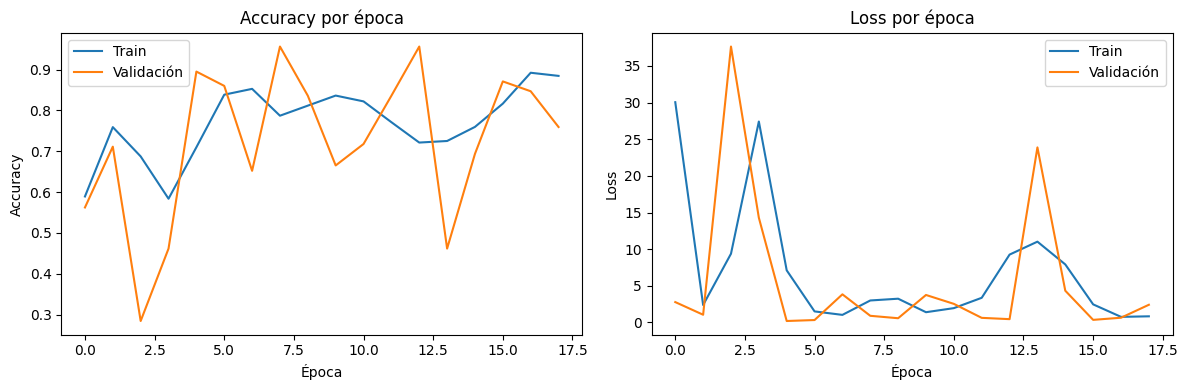

In [54]:
# --- 5. Visualizar desempeño ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Bien, los resultados si difieren considerablemente del train al test en cuanto al acuraccy.

Hablando de la perdida, parece que se estabiliza y se asemeja al train del test en su mayor parte.

Ahora evaluemos su comportamiento en la matriz de confusión.

> Nota: al parecer si vemos con atención, la grafica de accuracy, parece que al final el modelo trataba de estabilzarse, tal vez podria mejorar si aumentamos las epocas y le damos menos información para procesar a la vez, guardemos esa idea para mas tarde.

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy de Red Neuronal: 0.9500657030223391
F1-score de Red Neuronal: 0.4871967654986523


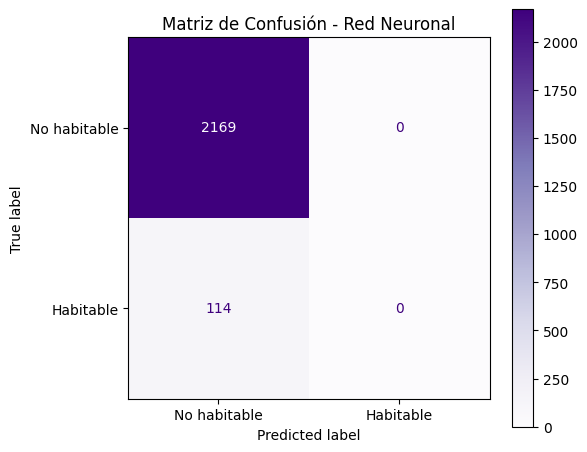

In [55]:
# --- 6. Evaluación ---
predNN = (model.predict(X_test) >= 0.5).astype(int)

accNN = accuracy_score(y_test, predNN)
f1NN  = f1_score(y_test, predNN, average="macro")

print(f"Accuracy de Red Neuronal: {accNN}")
print(f"F1-score de Red Neuronal: {f1NN}")

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, predNN),
                               display_labels=['No habitable', 'Habitable'])
disp.plot(cmap='Purples', ax=ax)
ax.set_title('Matriz de Confusión - Red Neuronal')
plt.tight_layout()
plt.show()

Parece que el accuracy o la precisión es bastante buena, sin embargo el f1-score no es tan prometedor ya que al parecer le cuesta distinguir entre un planeta y otro, esto lo confirmamos con la matriz de confusión, en donde no fue capaz de identificar a ningun planeta como habitable y ademas de eso, 114 planetas los cuales eran habitables, los marco como no habitables.

### Que pasaria si ?

Bien, retomando la idea que hicimos, que pasaria si aumentamos las epocas de entrenamiento y reducimos el batch size, esto para que procese menos planetas a la vez y tenga mas tiempo para aprender, sera posible que el F1-Score mejore?, mas bien, que el modelo mejore en general.

Averiguemoslo!

### Aumentar epocas y reducir batch size

Utilicemos lo mismo pero cambiando los siguientes parametros:
- batch_size: 16 ---->> (16 planetas a la vez, la mitad que se utilizaba en el ejercicio anterior)
- Epocas ------>> (utlicemos 100 epocas de entrenamiento)

Esto lo haremos en una unica celda para no hacer mas largo el reporte

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6073 - loss: 30.5191 - val_accuracy: 0.3085 - val_loss: 64.8120
Epoch 2/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7459 - loss: 8.3149 - val_accuracy: 0.9562 - val_loss: 1.2103
Epoch 3/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7640 - loss: 8.1677 - val_accuracy: 0.5208 - val_loss: 19.5680
Epoch 4/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7448 - loss: 11.5030 - val_accuracy: 0.8053 - val_loss: 1.6141
Epoch 5/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8527 - loss: 3.0946 - val_accuracy: 0.7243 - val_loss: 4.1129
Epoch 6/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8215 - loss: 3.4641 - val_accuracy: 0.7877 - val_loss: 2.2722
Epoch 7/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8001 - loss: 7.3473 - val_accuracy: 0.6958 - val_loss: 6.3484
Epoch 8/100
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8133 - loss: 6.4162 - val

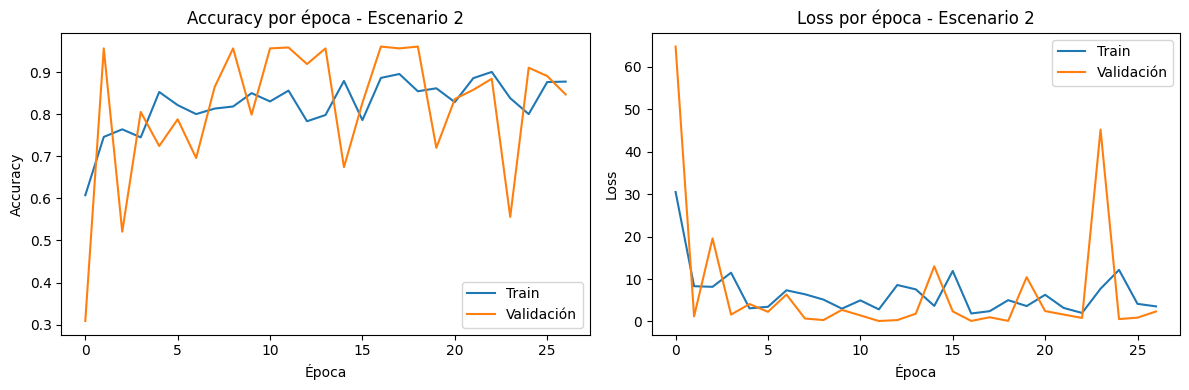

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy - Escenario 2: 0.9430573806395094
F1-score - Escenario 2: 0.7141412390198798


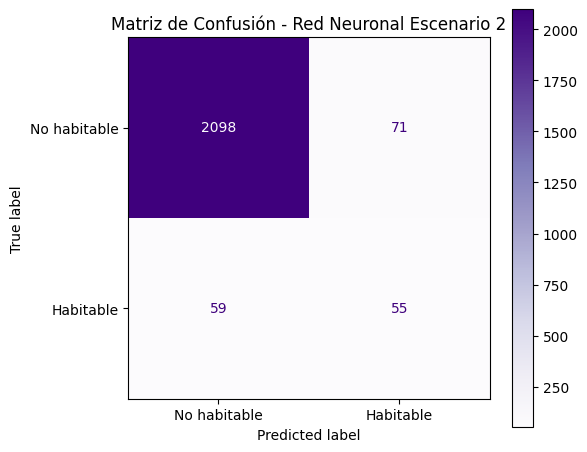

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# --- Escenario 2: batch_size=16, epochs=100 ---
model2 = Sequential()
model2.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(1,  activation='sigmoid'))

opt2 = Adam(learning_rate=0.001)
model2.compile(
    optimizer=opt2,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=16,             # batch más pequeño
    callbacks=[early_stop2],
    class_weight={0: 1, 1: 20}
)

# --- Visualizar desempeño ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train')
plt.plot(history2.history['val_accuracy'], label='Validación')
plt.title('Accuracy por época - Escenario 2')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train')
plt.plot(history2.history['val_loss'], label='Validación')
plt.title('Loss por época - Escenario 2')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# --- Métricas ---
predNN2 = (model2.predict(X_test) >= 0.5).astype(int)

accNN2 = accuracy_score(y_test, predNN2)
f1NN2  = f1_score(y_test, predNN2, average="macro")

print(f"Accuracy - Escenario 2: {accNN2}")
print(f"F1-score - Escenario 2: {f1NN2}")

# --- Matriz de confusión ---
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, predNN2),
                               display_labels=['No habitable', 'Habitable'])
disp.plot(cmap='Purples', ax=ax)
ax.set_title('Matriz de Confusión - Red Neuronal Escenario 2')
plt.tight_layout()
plt.show()

Enhorabuena!, si mejoro, ahora nuestro f1-score paso de 0.48 a - 0.71, de modo que el darle menos informacion y mas tiempo para aprender si mejoro un poco la calidad del modelo.

Es verdad que la linea del accuracy sigue discrepando del train al test, pero podemos ver que trata de seguir el comportamiento.

Con estos cambios en los parametros, ahora de no poder identificar ningun planeta como habitable, ahora podemos identificar 55 correctamente.

## Conclusiones

Wow, fueron bastantes modelos, pero ahora, toca hablar de las conclusiones.

### Comparacion de desempeño de modelos
| Modelo                              | Accuracy | F1-Score (macro) | OOB Score |
|-------------------------------------|----------|------------------|-----------|
| Random Forest                       | **0.9768** | **0.8718**  | **0.9750**  |
| Gradient Boosting                   | 0.876    | 0.8766        | N/A       |
| SVM                                 | 0.583    | 0.553         | N/A       |
| Red Neuronal (epochs=50, batch=32)  | 0.9501   | 0.4872        | N/A       |
| Red Neuronal (epochs=100, batch=16) | 0.943    | 0.714         | N/A       |

Si hablamos de desempeño, el modelo de random forest obtuvo los mejores resultados con un Accuracy de 0.976 y 0.8718, ya vimos que es la que tiene el mejor balance entre precisión, recall, f1-score, entre otros.

### Diferencias
Las diferencias son sustanciales, ya que tenemos mucha brecha entre un modelo y otro, principalmente en las metricas de desempeño, por lo que cada modelo es muy distinto, con resultados distintos, pueden tener similitudes pero siguen siendo distintos.

### Complejidad
Con estos resultados, vemos que a lo contrario que podriamos pensar, la complejidad no siempre trae consigo mejores resultados para un modelo. Podriamos decir que el modelo mas complejo es el de las redes neuronales, aunque este obtuvo buenos resultados en el accuracy, le sigue faltando bastante desempeño en el f1-score. Por lo tanto, en este caso, mayor complejidad del modelo no es igual a mejores resultados, a parecer es al contrario.

### Riesgo de sobreajuste
- **Random Forest**: riesgo moderado, árboles sin límite de profundidad pueden memorizar,
  aunque el OOB≈Accuracy en test indica que no ocurrió en este caso.
- **Gradient Boosting**: riesgo bajo, max_depth=3 y learning_rate=0.1 controlan la complejidad.
- **SVM**: riesgo bajo, C=1.0 es un valor conservador que penaliza sin sobreajustar.
- **Red Neuronal**: riesgo moderado-alto, las curvas inestables del escenario 1 sugieren
  problemas de convergencia, y el escenario 2 con más épocas aumenta ese riesgo.

### Interpretabilidad
- **Random Forest**: media, permite ver importancia de variables con feature_importances_.
- **Gradient Boosting**: media-baja, similar al RF pero más difícil de explicar.
- **SVM**: baja, el kernel RBF transforma los datos a un espacio no interpretable.
- **Red Neuronal**: muy baja, las decisiones se distribuyen entre cientos de pesos.

### ¿Cuándo preferir cada modelo?
- **Random Forest**: cuando se quiere buen rendimiento y entender qué variables importan.
- **Gradient Boosting**: cuando se prioriza detectar la mayor cantidad de positivos (habitables).
- **SVM**: cuando hay una separación clara entre clases y el dataset es pequeño.
- **Red Neuronal**: cuando el dataset es mucho más grande y los patrones son muy complejos.